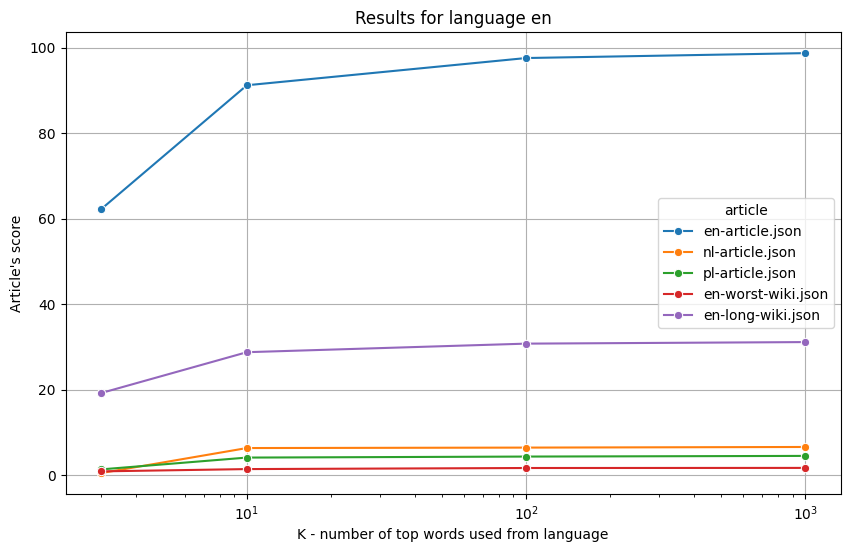

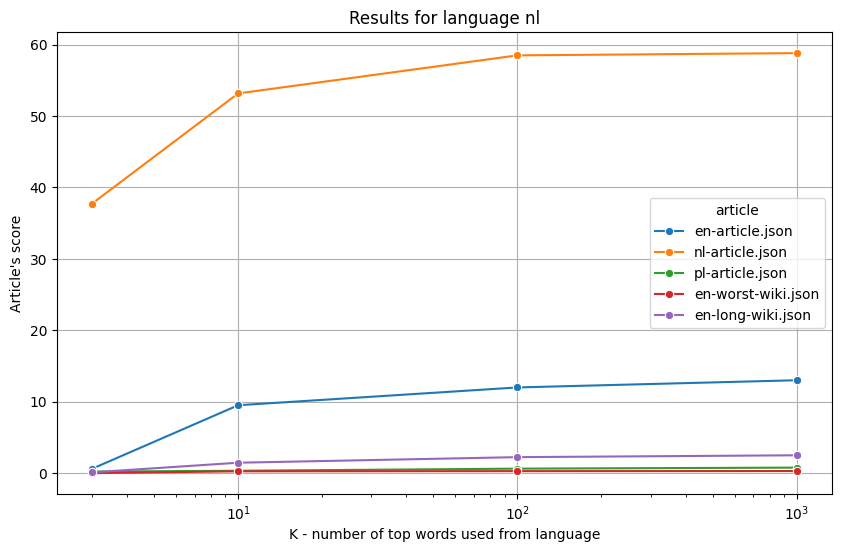

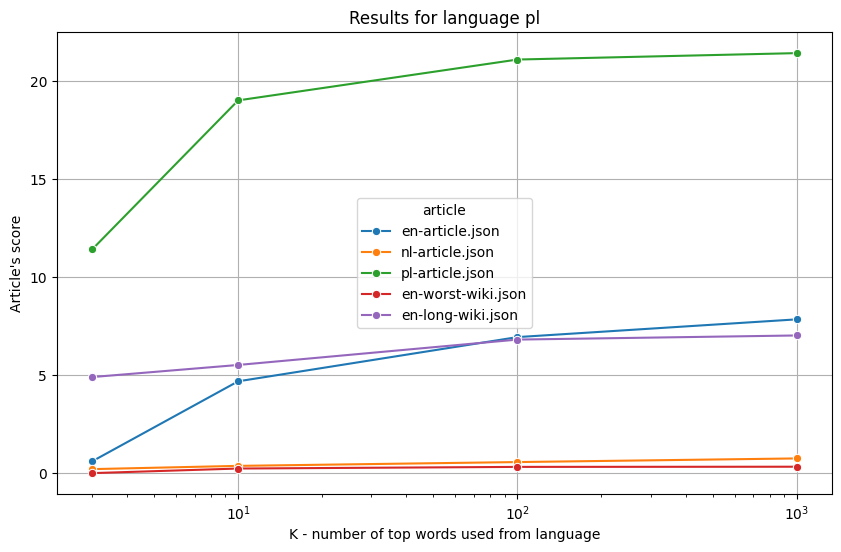

In [41]:
from wordfreq import word_frequency, top_n_list
from collections import Counter
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# preparing data
k_values = [3, 10, 100, 1000]
langs = ["en", "nl", "pl"]
art_files = ["en-article.json",
                 "nl-article.json",
                 "pl-article.json",
                 "en-worst-wiki.json",
                 "en-long-wiki.json",]

# dict for each language: word: word_frequency in this lanugage
top_words_data = {
    "en": {}, # english
    "pl": {}, # polish
    "nl": {} # dutch
}

for k in k_values:
    for lang in langs:
        top_words_data[lang][k] = {word: word_frequency(word=word, lang=lang)
                                   for word in top_n_list(lang=lang, n=k)}


def lang_confidence_score(word_counts, language_words_with_frequency):
    with open("analysis/" + word_counts, "r", encoding="utf-8") as file:
        text_counter = Counter(json.loads(file.read()))

    result = 0
    top_words = language_words_with_frequency.keys()
    for word, occurences in text_counter.items():
        if word in top_words:
            result += occurences * language_words_with_frequency[word]
    return result
    # przemnozyc przez stala zeby bylo ladniej? i usunac po przecinku?
results = []

for k in k_values:
    for lang in langs:
        for art_file in art_files:
            score = lang_confidence_score(word_counts=art_file,
                                          language_words_with_frequency=top_words_data[lang][k])
            results.append({
                "k": k,
                "tested_lang": lang,
                "article": art_file,
                "score": score
            })

df = pd.DataFrame(results)

for lang, group in df.groupby("tested_lang"):
    plt.figure(figsize=(10, 6))
    plt.xscale('log')
    plt.grid(True)
    sns.lineplot(data=group, x="k", y="score", hue="article", marker="o")
    plt.title(f"Result for language: {lang}")
    plt.ylabel("Article's score")
    plt.xlabel("K - number of top words used from language")
    plt.show()